1. Setup

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.api import VAR
from itertools import permutations

import warnings
warnings.filterwarnings('ignore')

2. Download data using yfinance

In [ ]:
inr = yf.download(tickers="INR=X", start="2019-01-01")
gold = yf.download(tickers="GC=F", start="2019-01-01")
crude = yf.download(tickers="CL=F", start="2019-01-01")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


3. Extract Close, combine and drop Nans

In [ ]:
inr_close = inr["Close"].rename(columns={"INR=X": "inr_close"})
gold_close = gold["Close"].rename(columns={"GC=F": "gold_close"})
crude_close = crude["Close"].rename(columns={"CL=F": "crude_close"})

combined = pd.concat([inr_close, gold_close, crude_close], axis=1).sort_index()
combined.columns.name = None

print("Before dropna:", combined.shape)
print(combined.isna().sum())

combined = combined.dropna()
print("After dropna:", combined.shape)
print(combined.index.min(), combined.index.max())

Before dropna: (2013, 3)
inr_close       2
gold_close     68
crude_close    69
dtype: int64
After dropna: (1942, 3)
2019-01-02 00:00:00 2026-09-23 00:00:00


4. Raw Price Plots

In [ ]:
for col, title in [("inr_close", "USD/INR"), ("gold_close", "Gold (USD)"), ("crude_close", "Crude Oil (USD)")]:
    fig = px.line(combined, x=combined.index, y=col, title=f"{title} Over Time")
    fig.show()

Note: Crude includes 20-04-2020, when WTI futures settled at **-$37.63/barrel**.

5. Log Transform

In [ ]:
log_combined = pd.DataFrame({
    "log_inr": np.log(combined["inr_close"]),
    "log_gold": np.log(combined["gold_close"]),
    "log_crude": np.log(combined["crude_close"]),
})

print(log_combined.isna().sum())
print(log_combined[log_combined["log_crude"].isna()])   # should be exactly 2020-04-20

log_inr      0
log_gold     0
log_crude    1
dtype: int64
             log_inr  log_gold  log_crude
Date                                     
2020-04-20  4.338075  7.439324        NaN


6. Stationary testing(ADF)

In [ ]:
def adf_report(series, label):
    s = series.dropna()
    result = adfuller(s)
    print(f"--- {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4g}")
    for key, value in result[4].items():
        print(f"\t{key}: {value:.4f}")
    verdict = "stationary" if result[1] <= 0.05 else "NON-stationary"
    print(f"Verdict: {verdict}\n")
    return result[1] <= 0.05

adf_report(log_combined["log_inr"], "log INR (level)")
adf_report(log_combined["log_gold"], "log GOLD (level)")
adf_report(log_combined["log_crude"], "log CRUDE (level)")

--- log INR (level) ---
ADF Statistic: 0.3651
p-value: 0.9801
	1%: -3.4338
	5%: -2.8630
	10%: -2.5676
Verdict: NON-stationary

--- log GOLD (level) ---
ADF Statistic: 0.1336
p-value: 0.9683
	1%: -3.4337
	5%: -2.8630
	10%: -2.5676
Verdict: NON-stationary

--- log CRUDE (level) ---
ADF Statistic: -2.4948
p-value: 0.1167
	1%: -3.4338
	5%: -2.8630
	10%: -2.5676
Verdict: NON-stationary



False

7. Fiest-differencing and re-test

In [ ]:
diff_inr = log_combined["log_inr"].dropna().diff().dropna()
diff_gold = log_combined["log_gold"].dropna().diff().dropna()
diff_crude = log_combined["log_crude"].dropna().diff().dropna()

adf_report(diff_inr, "log INR (differenced)")
adf_report(diff_gold, "log GOLD (differenced)")
adf_report(diff_crude, "log CRUDE (differenced)")

--- log INR (differenced) ---
ADF Statistic: -11.2991
p-value: 1.321e-20
	1%: -3.4338
	5%: -2.8630
	10%: -2.5676
Verdict: stationary

--- log GOLD (differenced) ---
ADF Statistic: -19.1799
p-value: 0
	1%: -3.4337
	5%: -2.8630
	10%: -2.5676
Verdict: stationary

--- log CRUDE (differenced) ---
ADF Statistic: -8.6289
p-value: 5.826e-14
	1%: -3.4338
	5%: -2.8630
	10%: -2.5676
Verdict: stationary



True

8. ACF/PACF on differenced series

In [ ]:
def plot_acf_pacf_plotly(series, label, lags=20):
    n = len(series)
    conf = 1.96 / np.sqrt(n)

    acf_vals = acf(series, nlags=lags)
    pacf_vals = pacf(series, nlags=lags)

    for vals, name in [(acf_vals, "ACF"), (pacf_vals, "PACF")]:
        fig = go.Figure()
        fig.add_trace(go.Bar(x=list(range(len(vals))), y=vals))
        fig.add_hline(y=conf, line_dash="dash", line_color="red")
        fig.add_hline(y=-conf, line_dash="dash", line_color="red")
        fig.update_layout(title=f"{name} — {label}", xaxis_title="Lag", yaxis_title=name)
        fig.show()

plot_acf_pacf_plotly(diff_inr, "differenced log INR")
plot_acf_pacf_plotly(diff_gold, "differenced log GOLD")
plot_acf_pacf_plotly(diff_crude, "differenced log CRUDE")

9. Train/Test Split

In [ ]:
TEST_SIZE = 60

def split(series, test_size=TEST_SIZE):
    s = series.dropna()
    return s.iloc[:-test_size], s.iloc[-test_size:]

train_inr, test_inr = split(log_combined["log_inr"])
train_gold, test_gold = split(log_combined["log_gold"])
train_crude, test_crude = split(log_combined["log_crude"])

for name, tr, te in [("INR", train_inr, test_inr), ("GOLD", train_gold, test_gold), ("CRUDE", train_crude, test_crude)]:
    print(f"{name}: train={len(tr)}, test={len(te)}")

INR: train=1882, test=60
GOLD: train=1882, test=60
CRUDE: train=1881, test=60


10. auto_arima on LEVEL series (train only)

In [ ]:
model_inr = auto_arima(train_inr, seasonal=False, trace=True, suppress_warnings=True)
print(model_inr.order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-15707.373, Time=6.86 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-15643.602, Time=0.97 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-15706.401, Time=0.76 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-15712.752, Time=1.90 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-15642.192, Time=0.79 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-15712.729, Time=2.36 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-15712.551, Time=3.93 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-15710.323, Time=1.16 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-15709.259, Time=0.21 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 19.017 seconds
(0, 1, 1)


In [ ]:
model_gold = auto_arima(train_gold, seasonal=False, trace=True, suppress_warnings=True)
print(model_gold.order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-11447.239, Time=1.43 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-11452.959, Time=0.21 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-11452.226, Time=0.23 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-11452.283, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-11449.676, Time=0.16 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-11451.958, Time=1.97 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 4.308 seconds
(0, 1, 0)


In [ ]:
model_crude = auto_arima(train_crude, seasonal=False, trace=True, suppress_warnings=True)
print(model_crude.order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-7380.368, Time=3.51 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-7324.531, Time=0.23 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-7324.356, Time=0.36 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-7324.805, Time=0.73 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-7326.452, Time=0.19 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-7337.522, Time=5.06 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-7321.622, Time=2.32 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-7389.077, Time=3.92 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-7364.490, Time=4.92 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-7387.689, Time=5.41 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=-7393.197, Time=5.25 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-7388.987, Time=6.22 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=-7384.818, Time=5.53 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept   : AIC=-7386.039, Time=8.00 sec
 ARIMA(2,1,4)(0,0,0

11. Fit ARIMA, forecast, evaluate

In [ ]:
def fit_forecast_eval(train, test, order, label, exog_train=None, exog_test=None):
    train_dates = train.index
    test_dates = test.index

    train_r = train.reset_index(drop=True)
    test_r = test.reset_index(drop=True)
    exog_train_r = exog_train.reset_index(drop=True) if exog_train is not None else None
    exog_test_r = exog_test.reset_index(drop=True) if exog_test is not None else None

    model = ARIMA(train_r, exog=exog_train_r, order=order)
    fitted = model.fit()

    forecast = fitted.forecast(steps=len(test_r), exog=exog_test_r)
    rmse = np.sqrt(mean_squared_error(test_r, forecast))
    mape = mean_absolute_percentage_error(test_r, forecast)

    print(f"--- {label} ARIMA{order}{' + exog' if exog_train is not None else ''} ---")
    print(f"RMSE (log scale): {rmse:.5f}")
    print(f"MAPE (log scale): {mape:.4%}\n")

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train_dates[-100:], y=train_r.values[-100:], name="train (last 100)"))
    fig.add_trace(go.Scatter(x=test_dates, y=test_r.values, name="actual"))
    fig.add_trace(go.Scatter(x=test_dates, y=forecast.values, name="forecast"))
    fig.update_layout(title=f"{label}: Actual vs Forecast (log scale)")
    fig.show()

    return fitted, forecast, rmse, mape

fitted_inr, fc_inr, rmse_inr, mape_inr = fit_forecast_eval(train_inr, test_inr, model_inr.order, "INR")

--- INR ARIMA(0, 1, 1) ---
RMSE (log scale): 0.01399
MAPE (log scale): 0.2803%



In [ ]:
fitted_gold, fc_gold, rmse_gold, mape_gold = fit_forecast_eval(train_gold, test_gold, model_gold.order, "GOLD")

--- GOLD ARIMA(0, 1, 0) ---
RMSE (log scale): 0.07853
MAPE (log scale): 0.7509%



In [ ]:
fitted_crude, fc_crude, rmse_crude, mape_crude = fit_forecast_eval(train_crude, test_crude, model_crude.order, "CRUDE")

--- CRUDE ARIMA(3, 1, 3) ---
RMSE (log scale): 0.20650
MAPE (log scale): 4.0080%



12. VAR: Combine differenced time series, split, lag-select, fit

In [ ]:
var_data = pd.DataFrame({
    "d_inr": log_combined["log_inr"].diff(),
    "d_gold": log_combined["log_gold"].diff(),
    "d_crude": log_combined["log_crude"].diff(),
}).dropna()

var_train = var_data.iloc[:-TEST_SIZE].reset_index(drop=True)
var_test = var_data.iloc[-TEST_SIZE:].reset_index(drop=True)

var_model = VAR(var_train).fit(7)
print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 23, Sep, 2026
Time:                     18:19:08
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -26.8655
Nobs:                     1872.00    HQIC:                  -26.9888
Log likelihood:           17426.0    FPE:                1.76893e-12
AIC:                     -27.0607    Det(Omega_mle):     1.70800e-12
--------------------------------------------------------------------
Results for equation d_inr
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.000250         0.000087            2.871           0.004
L1.d_inr          -0.192331         0.023253           -8.271           0.000
L1.d_gold         -0.025151         0.007451           -3.376           

13. Covariance Matrix

In [ ]:
corr_matrix = var_data.corr()
print(corr_matrix)

            d_inr    d_gold   d_crude
d_inr    1.000000  0.007975  0.055450
d_gold   0.007975  1.000000  0.064188
d_crude  0.055450  0.064188  1.000000


14. VAR forecast, convert back to log-level scale, compare RMSE vs ARIMA

In [ ]:
fc_input = var_train.values[-7:]
var_fc = pd.DataFrame(var_model.forecast(y=fc_input, steps=len(var_test)), columns=var_train.columns)

last_level = {"d_inr": train_inr.iloc[-1], "d_gold": train_gold.iloc[-1], "d_crude": train_crude.iloc[-1]}
var_level_fc = pd.DataFrame({c: last_level[c] + var_fc[c].cumsum() for c in var_fc.columns})

rmse_inr_var = np.sqrt(mean_squared_error(test_inr.reset_index(drop=True), var_level_fc["d_inr"]))
rmse_gold_var = np.sqrt(mean_squared_error(test_gold.reset_index(drop=True), var_level_fc["d_gold"]))
rmse_crude_var = np.sqrt(mean_squared_error(test_crude.reset_index(drop=True), var_level_fc["d_crude"]))

comparison = pd.DataFrame({
    "Series": ["INR","Gold","Crude"],
    "ARIMA RMSE": [rmse_inr, rmse_gold, rmse_crude],
    "VAR RMSE": [rmse_inr_var, rmse_gold_var, rmse_crude_var],
})
print(comparison)

  Series  ARIMA RMSE  VAR RMSE
0    INR    0.013988  0.009910
1   Gold    0.078531  0.052271
2  Crude    0.206501  0.197157


15. Impulse response functions

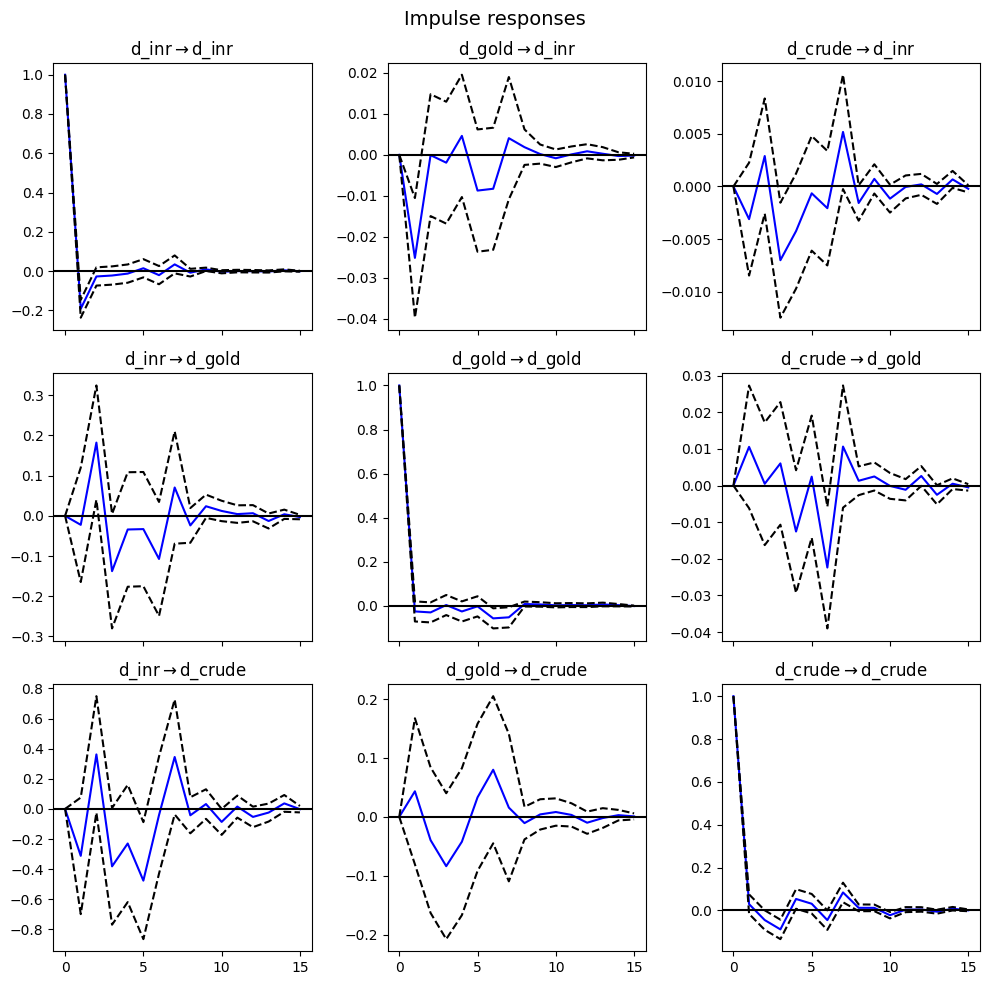

In [ ]:
irf = var_model.irf(15)
irf.plot(orth=False)
plt.tight_layout(); plt.show()

16. Rolling correlation (INR vs Gold, INR vs Crude)

In [ ]:
roll_gold = diff_inr.rolling(60).corr(diff_gold)
roll_crude = diff_inr.rolling(60).corr(diff_crude)
fig = go.Figure()
fig.add_trace(go.Scatter(x=roll_gold.index, y=roll_gold, name="INR-Gold"))
fig.add_trace(go.Scatter(x=roll_crude.index, y=roll_crude, name="INR-Crude"))
fig.update_layout(title="60-day Rolling Correlation of Returns")
fig.show()

17. Save models for future use

In [ ]:
fitted_inr.save("arima_inr.pkl")
fitted_gold.save("arima_gold.pkl")
fitted_crude.save("arima_crude.pkl")
var_model.save("var_model.pkl")
# VS Code: import statsmodels.api as sm; sm.load("arima_inr.pkl")
# VS Code VAR: from statsmodels.tsa.vector_ar.var_model import VARResultsWrapper; VARResultsWrapper.load("var_model.pkl")